# Simulating stuff with synthpop and ocelot!

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.gaia import Gaia
# import gaianir_open_clusters  # noqa: F401
from gaianir_open_clusters.cluster_model import GaiaNIRObservationModel
from gaianir_open_clusters.population import simulate_region
from ocelot.simulate import (
    SimulatedCluster,
    SimulatedClusterParameters,
    SimulatedClusterModels,
)
from ocelot.model.observation import (
    GaiaDR3ObservationModel,
    GenericSubsampleSelectionFunction,
)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/pydantic/_internal/_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)
 4583 - Location or solid_angle_sr are not  defined in the settings! Can not run main() or process_all()


Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 13.689 s
  pix_info:   0.175 s
   samples:   0.961 s
      best:   0.870 s
       nan:   0.011 s
      sort:  11.599 s
       idx:   0.073 s
Loading meta pixel info...
Meta pixel info loaded!


## Region sim!

In [2]:
l = 180
b = 0

In [3]:
region = simulate_region(l, b, 1/60**2, minimum_stars=10000)

Initializing populations for first time...
Simulating region... (attempt 1, area 1.000 arcsec^2)
  trying again; only have 153 stars
Simulating region... (attempt 2, area 130.719 arcsec^2)
  now adding photometry for 18972 stars...
Success! Calculating astrometry for 17133 remaining stars.


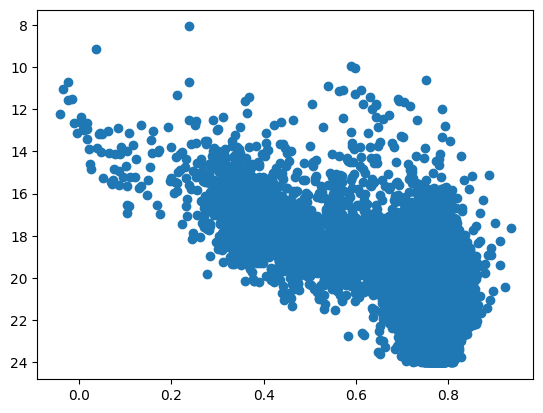

In [4]:
plt.scatter(region['N_J'] - region['N_K'], region['N'])
plt.gca().invert_yaxis()

## Cluster sim!

In [5]:
position = SkyCoord(
    l=l * u.deg,
    b=b * u.deg,
    distance=10000 * u.pc,
    pm_l_cosb=10 * u.mas / u.yr,
    pm_b=0 * u.mas / u.yr,
    radial_velocity=0 * u.km / u.s,
    frame="galactic",
)

parameters = SimulatedClusterParameters(
    position=position,
    mass=1000,
    log_age=9,
    metallicity=0.0,
    extinction=5.0,
    r_core=2,
    r_tidal=10,
    virial_ratio=0.5
)

In [6]:
Gaia.ROW_LIMIT = 10000
query = Gaia.cone_search(parameters.position, radius=0.5 * u.deg)
gaia_data = query.get_results().to_pandas().rename(columns={"SOURCE_ID": "source_id"})

In [7]:
models = SimulatedClusterModels(
    observations=[
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-L", years=10, maximum_magnitude=23
        ),
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-M", years=10, maximum_magnitude=23
        ),
        GaiaNIRObservationModel(
            mission_class="Gaia",
            years=10,
            maximum_magnitude=20,
            combined_astrometry=False,
        ),
        GaiaNIRObservationModel(
            mission_class="Gaia",
            years=5,
            maximum_magnitude=20,
            combined_astrometry=False,
        ),
        GaiaDR3ObservationModel(
            representative_stars=gaia_data, overestimate_bp_rp_fluxes=False
        ),
    ]
)

In [8]:
cluster = SimulatedCluster(random_seed=42, parameters=parameters, models=models)
cluster.make()

ValueError: The electron-based model is not correctly calibrated for Gaia - only GaiaNIR. Please just use the simpler AstrometryModel instead.

In [ ]:
cluster.observations.keys()

dict_keys(['gaianir-l-10-(combined)', 'gaianir-m-10-(combined)', 'gaia-10', 'gaia-5', 'gaia_dr3'])

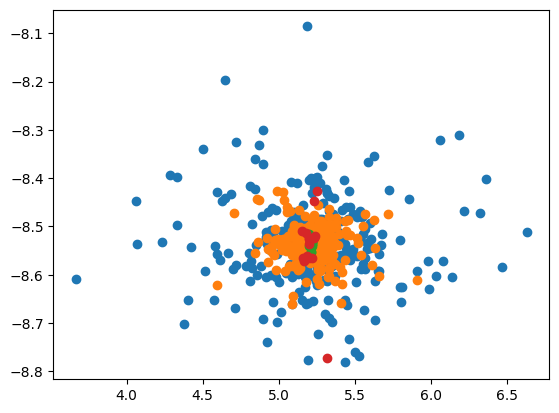

In [ ]:
obs_m = cluster.observations['gaianir-m-10-(combined)'].query("gaianir_n < 22")
obs_l = cluster.observations['gaianir-l-10-(combined)'].query("gaianir_n < 22")
obs_g = cluster.observations['gaia-10'].query("g_effective_gaia < 20")
obs_dr3 = cluster.observations['gaia_dr3'].query("gaia_dr3_g < 20")


plt.scatter(obs_m['pmra'], obs_m['pmdec'])
plt.scatter(obs_l['pmra'], obs_l['pmdec'])
plt.scatter(obs_g['pmra'], obs_g['pmdec'])
plt.scatter(obs_dr3['pmra'], obs_dr3['pmdec'])

[None]

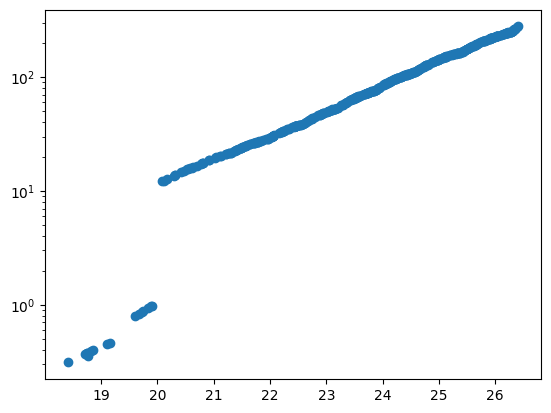

In [ ]:
plt.scatter(obs_l['g_effective_gaia'], obs_l['pmra_error']*1000)
plt.gca().set(yscale="log")

In [ ]:
region.keys()

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_None', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J',
       '2MASS_H', '2MASS_Ks', 'label', 'luminosity', 'temperature', 'log_g',
       'radius', 'N', 'N_R', 'N_J', 'N_H', 'N_K', 'extinction_green',
       'extinction_zucker', 'extinction', 'ra', 'dec', 'pmra_true',
       'pmdec_true', 'parallax_true', 'ra_error_gaianir-l',
       'dec_error_gaianir-l', 'pmra_error_gaianir-l', 'pmdec_error_gaianir-l',
       'parallax_error_gaianir-l', 'ra_error_gaianir-m', 'dec_error_gaianir-m',
       'pmra_error_gaianir-m', 'pmdec_error_gaianir-m',
       'parallax_error_gaianir-m', 'ra_error_gaia_dr4', 'dec_error_gaia_dr4',
       'pmra_error_gaia_dr4', 'pmdec_error_gaia_dr4',
       'parallax_error_gaia_dr4', 'ra_error_gaia_dr5', 'dec_error_gaia

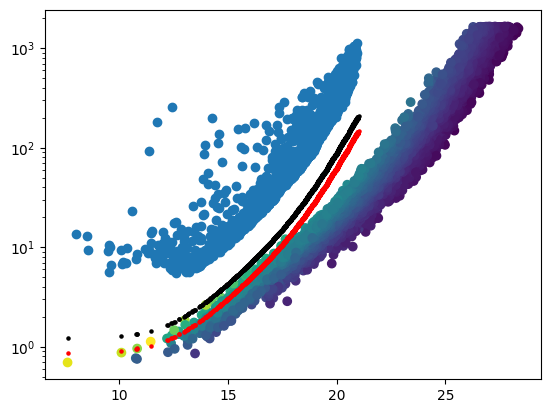

In [ ]:
plt.scatter(
    region["Gaia_G_EDR3"], region["pmra_error_gaianir-l"] * 1000, c=region["logTeff"]
)
plt.gca().set(yscale="log")

plt.scatter(region["Gaia_G_EDR3"], region["pmra_error_gaia_dr4"] * 1000, c="r", s=5)
plt.scatter(region["Gaia_G_EDR3"], region["pmra_error_gaia_dr5"] * 1000, c="k", s=5)

plt.scatter(
    gaia_data["phot_g_mean_mag"], gaia_data["pmra_error"] * 1000 / (2 * np.sqrt(2))
)